# 03 - Rate of climb, climb angle, ceilings and time to climb

References: Roskam & Lan, Chapter 9 (Secs. 9.1-9.7); Anderson, Secs. 5.10-5.12.
This notebook generalises `Capitolo8/RateoDiSalitaMotoelica/RateoDiSalita.ipynb`
(which computes the propeller-aircraft ceiling at point P of the polar) to jet
and propeller aircraft, steep climbs, accelerated climbs and time to climb.

In [1]:
# --- Setup -------------------------------------------------------------------
# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
import sys
import pathlib
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.atmosphere import isa
from aircraft_performance.plotting import apply_style, reference_line
from aircraft_performance.reporting import print_table

apply_style()
print(f"aircraft_performance v{ap.__version__} ready")

from aircraft_performance import climb, aerodynamics as aero
from aircraft_performance.aerodynamics import ParabolicDragPolar

single = ap.examples.light_single_piston()
atr = ap.examples.regional_turboprop()
jet = ap.examples.business_jet_giv()

aircraft_performance v1.0.0 ready


## 1. Equations of motion

Along and normal to a straight flight path inclined by $\gamma$ (Roskam Eqns 9.3-9.4):

$$
T - D - W\sin\gamma = \frac{W}{g}\frac{dV}{dt}, \qquad L - W\cos\gamma = 0
$$

(thrust aligned with the flight path). For **shallow** climbs ($\gamma \lesssim 15°$)
$\cos\gamma\approx1$, i.e. $L\approx W$, and at constant true airspeed:

$$
\boxed{RC = V\sin\gamma = \frac{(T-D)V}{W} = \frac{P_{av}-P_{req}}{W}},\qquad
\text{C.G.R.} = \sin\gamma = \frac{T-D}{W}
\qquad\text{(Eqns 9.11-9.12a)}
$$

The rate of climb is the **specific excess power**; the climb gradient is the
**specific excess thrust**.

* **Jet** (thrust independent of $V$): the steepest climb is at minimum drag,
  point E: $\sin\gamma_{max} = T/W - 1/E_{max}$ (Eqns 9.32-9.34). The best rate of
  climb occurs at the lift coefficient of Eqn (9.30):
  $C_L = -\frac{T}{W}\frac{\pi A e}{2}+\sqrt{\left(\frac{T}{W}\frac{\pi A e}{2}\right)^2+3C_{D_0}\pi A e}$,
  i.e. at a speed higher than $V_E$.
* **Propeller** (power independent of $V$): the best rate of climb is at minimum
  power required, point P (Eqn 9.57); the steepest climb occurs at a speed
  below $V_P$, often close to the stall.

## 2. Rate of climb versus speed and the hodograph

/tmp/ipykernel_4673/4172475875.py:4: PerformanceWarning: Maximum level speed: Mach number 1.141 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  s = ap.level_flight.level_flight_speeds(jet, h)
/tmp/ipykernel_4673/4172475875.py:4: PerformanceWarning: Maximum level speed: Mach number 1.317 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  s = ap.level_flight.level_flight_speeds(jet, h)
/tmp/ipykernel_4673/4172475875.py:4: PerformanceWarning: Maximum level speed: Mach number 1.543 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  s = ap.level_flight.level_flight_speeds(jet, h)


/tmp/ipykernel_4673/4172475875.py:4: PerformanceWarning: Maximum level speed: Mach number 1.775 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  s = ap.level_flight.level_flight_speeds(jet, h)


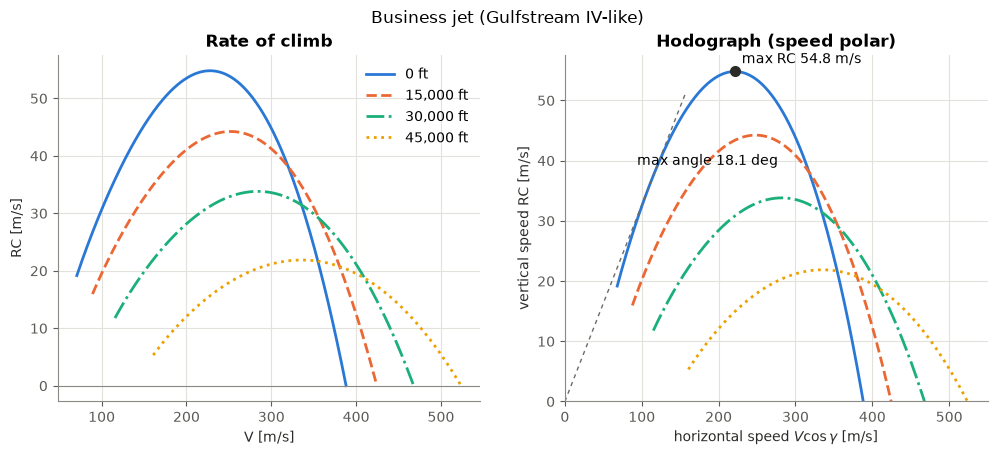

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for h_ft in (0, 15000, 30000, 45000):
    h = h_ft * u.FT
    s = ap.level_flight.level_flight_speeds(jet, h)
    V = np.linspace(s.V_stall, s.V_max, 300)
    rc = climb.rate_of_climb(jet, V, h)
    line, = a1.plot(V, rc, label=f"{h_ft:,} ft")
    a2.plot(V * np.cos(np.arcsin(rc / V)), rc, color=line.get_color(), linestyle=line.get_linestyle(),
            label=f"{h_ft:,} ft")
a1.set_xlabel("V [m/s]"); a1.set_ylabel("RC [m/s]"); a1.set_title("Rate of climb")
a1.axhline(0, color="#8a8a85", linewidth=0.8); a1.legend()

# hodograph at sea level: max RC = horizontal tangent, max angle = tangent from the origin
h = 0.0
best_rc = climb.max_rate_of_climb(jet, h)
best_ang = climb.max_climb_angle(jet, h)
Vh = best_ang.V * np.cos(best_ang.gamma)
a2.plot([0, 1.4 * Vh], [0, 1.4 * Vh * np.tan(best_ang.gamma)], color="#6b6b66", linewidth=1, linestyle=(0, (3, 3)))
a2.annotate(f"max angle {best_ang.gamma_deg:.1f} deg", (Vh, best_ang.rate), xytext=(-10, 12), textcoords="offset points")
a2.plot(best_rc.V * np.cos(best_rc.gamma), best_rc.rate, "o", color="#2b2b28")
a2.annotate(f"max RC {best_rc.rate:.1f} m/s", (best_rc.V * np.cos(best_rc.gamma), best_rc.rate),
            xytext=(5, 6), textcoords="offset points")
a2.set_xlim(left=0); a2.set_ylim(bottom=0)
a2.set_xlabel("horizontal speed $V\\cos\\gamma$ [m/s]"); a2.set_ylabel("vertical speed RC [m/s]")
a2.set_title("Hodograph (speed polar)")
fig.suptitle(jet.name)
plt.show()

## 3. Jet: numerical versus closed form, and Anderson's table

`climb.max_rate_of_climb` maximises $(T-D)V/W$ numerically for any aircraft;
`climb.jet_max_rate_of_climb_parabolic` applies Roskam Eqn (9.30). They must agree
for a jet with constant thrust, and both must reproduce the table of Anderson
Example 5.16 (ft/s).

In [3]:
anderson = {0: 179.9, 10000: 156.6, 20000: 133.8, 30000: 111.0, 40000: 85.9, 50000: 58.2, 60000: 30.1}
rows = []
for h_ft, ref in anderson.items():
    h = h_ft * u.FT
    num = climb.max_rate_of_climb(jet, h)
    cf = climb.jet_max_rate_of_climb_parabolic(jet.weight, jet.wing_area, isa(h).density, jet.polar(),
                                              jet.propulsion.thrust_available(0.0, h))
    rows.append([h_ft, num.rate / u.FT, cf.rate / u.FT, ref, num.V / u.FT, num.V / isa(h).speed_of_sound])
print_table(["h [ft]", "RC numerical [ft/s]", "RC Eqn 9.30 [ft/s]", "Anderson [ft/s]", "V [ft/s]", "Mach"], rows,
            ["{:,.0f}", "{:.1f}", "{:.1f}", "{:.1f}", "{:.1f}", "{:.2f}"])

ang = climb.jet_max_climb_angle_parabolic(jet.weight, jet.wing_area, isa(0).density, jet.polar(),
                                         jet.propulsion.max_thrust_sl)
print(f"\nSteepest climb at sea level: {ang.gamma_deg:.2f} deg at {ang.V/u.FT:.1f} ft/s "
      "(Anderson Example 5.13: 18.07 deg at 376.8 ft/s)")

h [ft]  RC numerical [ft/s]  RC Eqn 9.30 [ft/s]  Anderson [ft/s]  V [ft/s]  Mach
------  -------------------  ------------------  ---------------  --------  ----
     0                179.8               179.8            179.9     747.3  0.67
10,000                156.6               156.6            156.6     798.1  0.74
20,000                133.8               133.8            133.8     858.4  0.83
30,000                111.0               111.0            111.0     932.2  0.94
40,000                 85.8                85.8             85.9    1034.3  1.07
50,000                 57.9                57.9             58.2    1178.4  1.22
60,000                 29.7                29.7             30.1    1362.0  1.41

Steepest climb at sea level: 18.07 deg at 376.8 ft/s (Anderson Example 5.13: 18.07 deg at 376.8 ft/s)


/tmp/ipykernel_4673/180778102.py:5: PerformanceWarning: Best rate-of-climb speed: Mach number 0.937 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  num = climb.max_rate_of_climb(jet, h)
/tmp/ipykernel_4673/180778102.py:5: PerformanceWarning: Best rate-of-climb speed: Mach number 1.068 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  num = climb.max_rate_of_climb(jet, h)
/tmp/ipykernel_4673/180778102.py:5: PerformanceWarning: Best rate-of-climb speed: Mach number 1.217 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  num = climb.max_rate_of_climb(jet, h)
/tmp/ipykernel_4673/180778102.py:5: PerformanceWarning: Best rate-of-climb speed: Mach number 1.407 exceeds the drag-divergence Mach number 0.850 of

As in Anderson's text, above ~30,000 ft the best-RC speeds exceed the
drag-divergence Mach number: the warnings remind us that the parabolic polar is
optimistic there.

## 4. Propeller aircraft: Roskam Example 9.2 and steep climbs

Roskam Example 9.2: a twin turboprop ($W = 36{,}000$ lb, $S = 450$ ft$^2$,
$C_D = 0.02+0.05C_L^2$) is given the power that yields 400 kt at sea level. The
6-step procedure of Sec. 9.3.1.2 (best RC at point P) gives 5,116 ft/min at
147 kt and $\gamma = 19.5°$ - too steep for the small-angle theory, so Roskam
re-solves the exact quadratic Eqn (9.64): $\gamma = 20.4°$. (Roskam rounds
$RC/V = 0.344$ rad to 0.34 rad, hence his 19.5° instead of 19.7°.)

In [4]:
W, S = 36000 * u.LBF, 450 * u.FT2
pol = ParabolicDragPolar(CD0=0.02, K=0.05)
rho0 = isa(0.0).density
V_max = 400 * u.KT
CL = aero.lift_coefficient(W, S, rho0, V_max)
THP = 0.5 * rho0 * V_max**3 * S * (pol.drag_coefficient(CL) + 0.0015)   # + compressibility increment
best = climb.propeller_max_rate_of_climb_parabolic(W, S, rho0, pol, THP)
sin_g = climb.propeller_steep_climb_sin_gamma(THP, W, best.V, best.CL, pol.drag_coefficient(best.CL))
print_table(["quantity", "this code", "Roskam"],
            [["THP available [hp]", THP / u.HP, 6768],
             ["CL best RC", best.CL, 1.095],
             ["V best RC [kt]", best.V / u.KT, 147],
             ["RC max [ft/min]", best.rate_fpm, 5116],
             ["gamma = RC/V [deg] (small angle)", np.degrees(best.rate / best.V), 19.5],
             ["gamma exact, Eqn 9.64 [deg]", np.degrees(np.arcsin(sin_g)), 20.4]],
            ["{}", "{:.3f}", "{:.3f}"])

                        quantity  this code    Roskam
--------------------------------  ---------  --------
              THP available [hp]   6759.386  6768.000
                      CL best RC      1.095     1.095
                  V best RC [kt]    146.871   147.000
                 RC max [ft/min]   5109.902  5116.000
gamma = RC/V [deg] (small angle)     19.684    19.500
     gamma exact, Eqn 9.64 [deg]     20.373    20.400


The package also solves the **fully consistent** steep-climb problem
(`climb.steep_climb`): $T - D(C_L) = W\sin\gamma$ with $C_L = 2W\cos\gamma/(\rho V^2S)$,
without the iteration of Roskam's Steps 1-8. For shallow climbs it reduces to the
small-angle result:

In [5]:
rows = []
for V in (35.0, 40.0, 45.0, 55.0):
    exact = climb.steep_climb(single, V, 0.0)
    small = climb.rate_of_climb(single, V, 0.0)
    rows.append([V, small, exact.rate, np.degrees(np.arcsin(small / V)), exact.gamma_deg])
print(single.name + " at sea level")
print_table(["V [m/s]", "RC small-angle", "RC exact", "gamma small [deg]", "gamma exact [deg]"], rows,
            ["{:.0f}", "{:.3f}", "{:.3f}", "{:.2f}", "{:.2f}"])

Light single-engine piston (C172-like) at sea level
V [m/s]  RC small-angle  RC exact  gamma small [deg]  gamma exact [deg]
-------  --------------  --------  -----------------  -----------------
     35           5.472     5.513               8.99               9.06
     40           5.103     5.127               7.33               7.36
     45           4.525     4.538               5.77               5.79
     55           2.708     2.710               2.82               2.82


## 5. Maximum rate of climb versus altitude, ceilings

Roskam Sec. 9.4.3 defines:

| ceiling | condition |
|---|---|
| absolute | $RC_{max} = 0$ |
| service (piston/propeller, civil) | $RC_{max} = 100$ ft/min (0.508 m/s) |
| service (jet, civil) | $RC_{max} = 500$ ft/min (2.54 m/s) |
| cruise (military, $M<1$) | $RC_{max} = 300$ ft/min |

`climb.ceilings` finds them by root-finding on $RC_{max}(h)$; each evaluation is a
full optimisation over speed.

19 PerformanceWarnings collected; the last one says:
  Best rate-of-climb speed: Mach number 1.642 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).



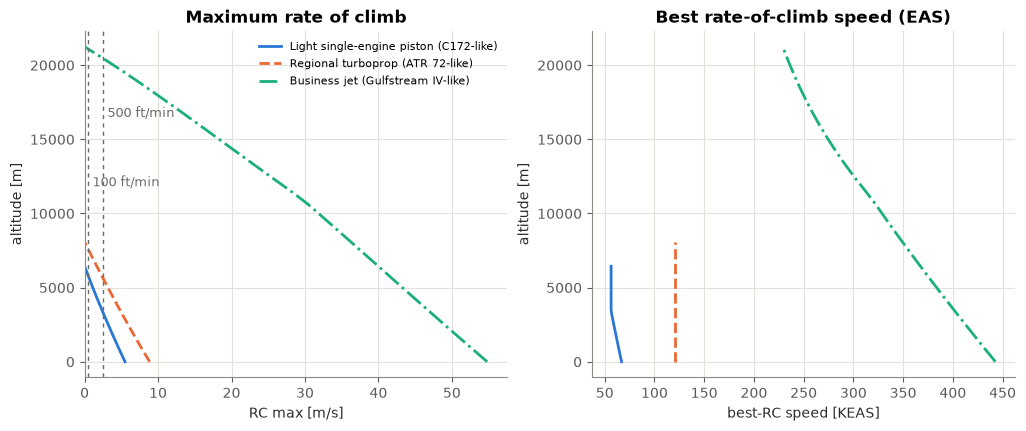

                              aircraft  RC0 [m/s]  RC0 [ft/min]  service ceiling [m]  absolute ceiling [m]
--------------------------------------  ---------  ------------  -------------------  --------------------
Light single-engine piston (C172-like)       5.50          1083                 5774                  6443
      Regional turboprop (ATR 72-like)       8.86          1744                 7565                  8063
     Business jet (Gulfstream IV-like)      54.81         10789                20454                 21244


In [6]:
import warnings
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
rows = []
# Collect the PerformanceWarnings instead of printing dozens of them, then summarise
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always", ap.PerformanceWarning)
    results = {}
    for aircraft in (single, atr, jet):
        c = climb.ceilings(aircraft)
        hs = np.linspace(0.0, c.absolute, 25)
        results[aircraft.name] = (c, hs, climb.max_rate_of_climb_vs_altitude(aircraft, hs))
print(f"{len(caught)} PerformanceWarnings collected; the last one says:\n  {caught[-1].message}\n" if caught else "")
for aircraft in (single, atr, jet):
    c, hs, data = results[aircraft.name]
    line, = a1.plot(data["RC_max"], hs, label=aircraft.name)
    a2.plot(data["V_best_RC"] * np.sqrt(isa(hs).sigma) / u.KT, hs, color=line.get_color(),
            linestyle=line.get_linestyle(), label=aircraft.name)
    rows.append([aircraft.name, data["RC_max"][0], data["RC_max"][0] / u.FPM, c.service, c.absolute])
reference_line(a1, 100 * u.FPM, label="100 ft/min", label_position=0.6)
reference_line(a1, 500 * u.FPM, label="500 ft/min", label_position=0.8)
a1.set_xlabel("RC max [m/s]"); a1.set_ylabel("altitude [m]"); a1.set_title("Maximum rate of climb")
a1.set_xlim(left=0); a1.legend(fontsize=8)
a2.set_xlabel("best-RC speed [KEAS]"); a2.set_ylabel("altitude [m]"); a2.set_title("Best rate-of-climb speed (EAS)")
plt.show()
print_table(["aircraft", "RC0 [m/s]", "RC0 [ft/min]", "service ceiling [m]", "absolute ceiling [m]"], rows,
            ["{}", "{:.2f}", "{:.0f}", "{:.0f}", "{:.0f}"])

Three remarks:

1. $RC_{max}(h)$ is almost linear for the propeller aircraft - the basis of the
   linearised model of Roskam Eqn (9.73), used below.
2. For the propeller aircraft the best-RC **equivalent** airspeed is nearly
   constant with altitude, which is why they climb at constant indicated
   airspeed. For the jet it decreases markedly (while the true airspeed and the
   Mach number increase): jets therefore climb at constant calibrated airspeed
   and then, above a crossover altitude, at constant Mach number - a practical
   compromise discussed in Roskam Sec. 9.5.
3. The **jet** ceiling (~21 km) is *not* credible: it is reached at a best-RC
   Mach number of about 1.6, far beyond drag divergence, as the collected
   warnings say. With the transonic drag rise the real Gulfstream IV is
   thrust-limited around 14-15 km (and certified to 45,000 ft). The parabolic
   polar must be supplemented with a compressibility model before trusting
   jet ceilings - exactly the caveat of Anderson Example 5.6.
4. The light single's ceiling (~6.4 km) is consistent with the result of the
   `Capitolo8` notebook, which used the density-ratio lapse $P = P_0\sigma$ instead of
   the Gagg-Ferrar law used here.

## 6. Accelerated climb: the acceleration factor (Roskam Sec. 9.5)

If the true airspeed changes with altitude, part of the excess power becomes
kinetic energy (Eqns 9.10, 9.79-9.80):

$$
RC = \frac{(T-D)V/W}{1 + \dfrac{V}{g}\dfrac{dV}{dh}}
$$

* constant EAS in the troposphere: $\frac{V}{g}\frac{dV}{dh} \approx 0.567\,M^2$ (Eqn 9.84);
* constant Mach in the troposphere: $\approx -0.133\,M^2$ (Eqn 9.87) - the climb
  rate *increases*, because the speed of sound (hence the TAS) decreases;
* constant Mach in the isothermal stratosphere: $0$.

The package differentiates the actual speed schedule numerically. The table
repeats Roskam Table 9.10 and adds the closed form of Eqn (9.84). The
numerical values coincide with Eqn (9.84) in the troposphere (the 40,000 ft
row is in the stratosphere, where Eqn 9.84 does not apply); Roskam's table instead reads the
factor from his Fig. 9.24 (Boeing data, calibrated airspeed with compressibility
correction) and shows smaller values for the jet at high altitude.

In [7]:
roskam = {"prop 120 kt": [0.018, 0.025, 0.038, 0.060, 0.115], "jet 280 kt": [0.096, 0.135, 0.188, 0.265, 0.0]}
rows = []
for i, h_ft in enumerate((0, 10000, 20000, 30000, 40000)):
    h = h_ft * u.FT
    row = [h_ft]
    for label, V_eas_kt in (("prop 120 kt", 120), ("jet 280 kt", 280)):
        if label.startswith("jet") and h_ft == 40000:      # Roskam: the jet flies at constant Mach up there
            M = V_eas_kt * u.KT / np.sqrt(isa(h).sigma) / isa(h).speed_of_sound
            f = climb.acceleration_factor_constant_mach(M, h)
        else:
            f = climb.acceleration_factor_constant_eas(V_eas_kt * u.KT, h)
        V = V_eas_kt * u.KT / np.sqrt(isa(h).sigma)
        eqn = 0.0 if (label.startswith("jet") and h_ft == 40000) else \
            climb.acceleration_factor_roskam_troposphere(V / isa(h).speed_of_sound, "eas")
        row += [f, eqn, roskam[label][i], 1 / (1 + f)]
    rows.append(row)
print_table(["h [ft]", "prop: f", "Eqn 9.84", "Tab. 9.10", "RC ratio", "jet: f", "Eqn 9.84", "Tab. 9.10", "RC ratio"],
            rows, ["{:,.0f}"] + ["{:.3f}"] * 8)

h [ft]  prop: f  Eqn 9.84  Tab. 9.10  RC ratio  jet: f  Eqn 9.84  Tab. 9.10  RC ratio
------  -------  --------  ---------  --------  ------  --------  ---------  --------
     0    0.019     0.019      0.018     0.982   0.102     0.102      0.096     0.908
10,000    0.027     0.027      0.025     0.974   0.148     0.148      0.135     0.871
20,000    0.041     0.041      0.038     0.961   0.221     0.221      0.188     0.819
30,000    0.063     0.063      0.060     0.941   0.342     0.342      0.265     0.745
40,000    0.124     0.101      0.115     0.889   0.000     0.000      0.000     1.000


Neglecting the acceleration factor overestimates the jet's climb rate by about
10 % at sea level and 25-35 % at 30,000 ft (Roskam, with his Fig. 9.24: 9 % and
21 %), whereas for the slow propeller transport the effect is only 2-6 %.

## 7. Time to climb, distance and fuel (Roskam Sec. 9.4.1)

$$
t = \int_{h_1}^{h_2}\frac{dh}{RC_{max}(h, W)},\qquad
s = \int V\cos\gamma\,dt, \qquad W_f = \int \dot W_f\,dt
$$

evaluated numerically in altitude steps as in Roskam Table 9.6, with the weight
updated by the fuel burnt. For comparison, if $RC_{max}$ decreases linearly from
$RC_0$ to zero at the absolute ceiling (Eqns 9.73-9.74):

$$
t = \frac{h_{abs}}{RC_0}\,\ln\frac{1}{1-h/h_{abs}}
$$

which diverges at the absolute ceiling - the reason why the service ceiling is
a more useful operational limit.

Regional turboprop (ATR 72-like): climb from 0 to 6000 m at maximum continuous power
                             method  time [min]  distance [km]  fuel [kg]
-----------------------------------  ----------  -------------  ---------
      numerical, steady (Table 9.6)        21.1           93.8        296
numerical, with acceleration factor        21.7           96.6        304
             linear RC(h), Eqn 9.74        20.7              -          -


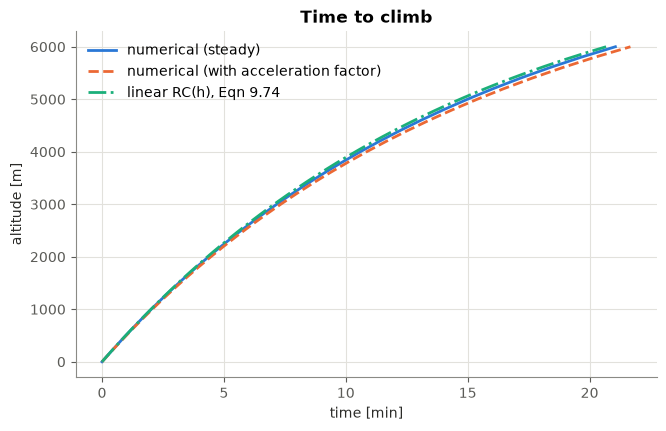

In [8]:
c = climb.ceilings(atr)
rc0 = climb.max_rate_of_climb(atr, 0.0).rate
h_target = 6000.0
prof = climb.time_to_climb(atr, 0.0, h_target, n_steps=30)
prof_acc = climb.time_to_climb(atr, 0.0, h_target, n_steps=30, accelerated=True)
t_lin = climb.time_to_climb_linear(rc0, c.absolute, h_target)
print(f"{atr.name}: climb from 0 to {h_target:.0f} m at maximum continuous power")
print_table(["method", "time [min]", "distance [km]", "fuel [kg]"],
            [["numerical, steady (Table 9.6)", prof.total_time / 60, prof.total_distance / 1000, prof.total_fuel_weight / u.G0],
             ["numerical, with acceleration factor", prof_acc.total_time / 60, prof_acc.total_distance / 1000, prof_acc.total_fuel_weight / u.G0],
             ["linear RC(h), Eqn 9.74", t_lin / 60, None, None]],
            ["{}", "{:.1f}", "{:.1f}", "{:.0f}"])

fig, ax = plt.subplots()
ax.plot(prof.time / 60, prof.altitude, label="numerical (steady)")
ax.plot(prof_acc.time / 60, prof_acc.altitude, label="numerical (with acceleration factor)")
hh = np.linspace(0, h_target, 50)
ax.plot(climb.time_to_climb_linear(rc0, c.absolute, hh) / 60, hh, label="linear RC(h), Eqn 9.74")
ax.set_xlabel("time [min]"); ax.set_ylabel("altitude [m]"); ax.set_title("Time to climb")
ax.legend()
plt.show()

Roskam's own check (p. 410): $RC_0 = 1{,}850$ ft/min and $h_{abs} = 32{,}000$ ft
give 48 min to 30,000 ft with Eqn (9.74):

In [9]:
print(f"{climb.time_to_climb_linear(1850 * u.FPM, 32000 * u.FT, 30000 * u.FT) / 60:.1f} min")

48.0 min


## 8. One engine inoperative: second-segment climb gradient

FAR 25.121 requires, with the critical engine inoperative, landing gear up and
take-off flaps, a minimum **climb gradient** at $V_2$ (Roskam Table 9.11):
2.4 % for twins, 2.7 % for three-engine and 3.0 % for four-engine aircraft.
With OEI the thrust halves (for a twin) and the drag increases (windmilling
propeller or engine, rudder and aileron trim, Roskam Fig. 9.27), modelled here
with an extra $\Delta C_{D_0}$.

In [10]:
rows = []
for aircraft, dCD0 in ((atr, 0.005), (jet, 0.003)):
    conf = aircraft.config("takeoff")
    W = aircraft.weight
    V2 = 1.2 * aero.stall_speed(W, aircraft.wing_area, isa(0).density, conf.CL_max)
    n_oei = aircraft.propulsion.n_engines - 1
    rc_aeo = climb.rate_of_climb(aircraft, V2, 0.0, config="takeoff")
    rc_oei = climb.rate_of_climb(aircraft, V2, 0.0, config="takeoff", n_operative=n_oei, extra_CD0=dCD0)
    rows.append([aircraft.name, V2 / u.KT, 100 * rc_aeo / V2, 100 * rc_oei / V2, 2.4,
                 "OK" if rc_oei / V2 >= 0.024 else "NOT met"])
print_table(["aircraft", "V2 [kt]", "gradient AEO [%]", "gradient OEI [%]", "required [%]", "FAR 25.121(b)"],
            rows, ["{}", "{:.0f}", "{:.1f}", "{:.1f}", "{:.1f}", "{}"])

                         aircraft  V2 [kt]  gradient AEO [%]  gradient OEI [%]  required [%]  FAR 25.121(b)
---------------------------------  -------  ----------------  ----------------  ------------  -------------
 Regional turboprop (ATR 72-like)      126              12.7               2.1           2.4        NOT met
Business jet (Gulfstream IV-like)      133              25.1               5.9           2.4             OK


The OEI gradient is what sizes the installed thrust of twin-engine airliners:
losing half of the thrust removes much *more* than half of the excess thrust.
With the simplified model used here (constant $\eta_p$, windmilling drag
guessed as $\Delta C_{D_0}=0.005$) the turboprop misses the requirement at
maximum take-off weight: its take-off weight would have to be reduced
(exercise 3), or a higher take-off power rating used.

## 9. Exercises

1. Compute the absolute ceiling of the business jet with one engine inoperative
   (`n_operative=1`) and compare it with the AEO value.
2. Repeat the ceiling calculation of the light single on an ISA+20 day
   (`delta_T=20`).
3. Find the weight of the turboprop for which the OEI second-segment gradient is
   exactly 2.4 % (hint: bisection on `weight`).